# Diffusion Models for High-Resolution Image Generation & Reconstruction
### DDPM Implementation from Scratch using PyTorch (Google Colab Version)

**Architecture Overview:**
- Forward Process: Gradual Gaussian noise addition (linear beta schedule)
- Reverse Process: U-Net backbone learns to predict and remove noise
- Training: MSE loss between predicted and actual noise
- Evaluation: PSNR + SSIM metrics
- Deployment: Gradio app with step-by-step denoising visualization

In [1]:
# 1. Install required libraries
!pip install -q gradio scikit-image torchmetrics kaggle

# 2. Upload Kaggle API Key
import os
from google.colab import files

print("Please upload your kaggle.json file (Downloaded from Kaggle Account Settings):")
uploaded = files.upload()

# 3. Configure Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download and extract the dataset directly to Colab
print("Downloading CelebA-HQ dataset...")
!kaggle datasets download -d denislukovnikov/celebahq256-images-only

print("Extracting dataset...")
!unzip -q celebahq256-images-only.zip -d /content/dataset
print("Setup complete! Dataset is ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.2 MB/s eta 0:00:00
Please upload your kaggle.json file (Downloaded from Kaggle Account Settings):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/denislukovnikov/celebahq256-images-only
License(s): unknown
100% 2.81G/2.81G [02:57<00:00, 17.0MB/s]

Extracting dataset...
Setup complete! Dataset is ready.


In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device Setup ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus  = torch.cuda.device_count()
print(f'Using device : {device}')
print(f'GPUs available: {n_gpus}')
for i in range(n_gpus):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Using device : cuda
GPUs available: 1
  GPU 0: Tesla T4


In [5]:
# ═══════════════════════════════════════════════════════════════
#  CENTRAL CONFIGURATION  –  Google Colab Settings
# ═══════════════════════════════════════════════════════════════
class Config:
    # Data
    DATA_DIR        = '/content/dataset/celebahq256_imgs'  # Colab dataset path
    IMG_SIZE        = 64          # 64 for fast training; use 128/256 for higher quality
    BATCH_SIZE      = 16
    NUM_WORKERS     = 2           # 2 is optimal for Colab free tier

    # Diffusion
    T               = 300         # total diffusion timesteps
    BETA_START      = 1e-4
    BETA_END        = 0.02

    # U-Net
    BASE_CHANNELS   = 64          # channel progression: 64→128→256
    TIME_EMB_DIM    = 256
    NUM_RES_BLOCKS  = 2

    # Training
    EPOCHS          = 30
    LR              = 2e-4
    GRAD_CLIP       = 1.0
    MIXED_PRECISION = True

    # Sampling
    NUM_SAMPLE_IMGS = 5

    # Paths
    SAVE_DIR        = '/content/ddpm_checkpoints'
    os.makedirs(SAVE_DIR, exist_ok=True)

cfg = Config()
print('Config loaded ✓')
print(f'  Image size   : {cfg.IMG_SIZE}x{cfg.IMG_SIZE}')
print(f'  Timesteps T  : {cfg.T}')
print(f'  Epochs       : {cfg.EPOCHS}')

Config loaded ✓
  Image size   : 64x64
  Timesteps T  : 300
  Epochs       : 30


Found 30,000 images in /content/dataset/celebahq256_imgs
Batches per epoch: 1,875


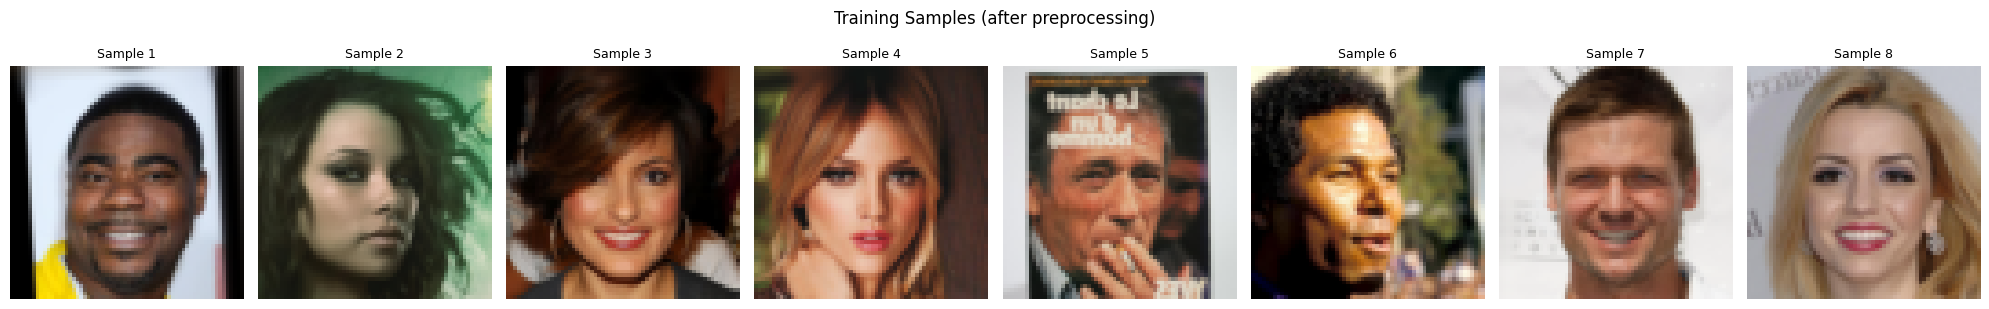

In [6]:
class ImageFolderDataset(Dataset):
    """Recursively loads all images from a directory tree."""
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir  = Path(root_dir)
        self.transform = transform
        self.paths = [
            p for p in self.root_dir.rglob('*')
            if p.suffix.lower() in self.EXTENSIONS
        ]
        print(f'Found {len(self.paths):,} images in {root_dir}')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                            # [0,1]
    transforms.Normalize((0.5, 0.5, 0.5),
                          (0.5, 0.5, 0.5)),           # → [-1, 1]
])

dataset    = ImageFolderDataset(cfg.DATA_DIR, transform=train_transform)
dataloader = DataLoader(
    dataset,
    batch_size  = cfg.BATCH_SIZE,
    shuffle     = True,
    num_workers = cfg.NUM_WORKERS,
    pin_memory  = True,
    drop_last   = True,
)
print(f'Batches per epoch: {len(dataloader):,}')

sample_batch = next(iter(dataloader))

# ── Visualise sample images ───────────────────────────────────────────────────
def denorm(tensor):
    """[-1,1] → [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in enumerate(axes):
    img_np = denorm(sample_batch[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.axis('off')
    ax.set_title(f'Sample {i+1}', fontsize=9)
plt.suptitle('Training Samples (after preprocessing)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

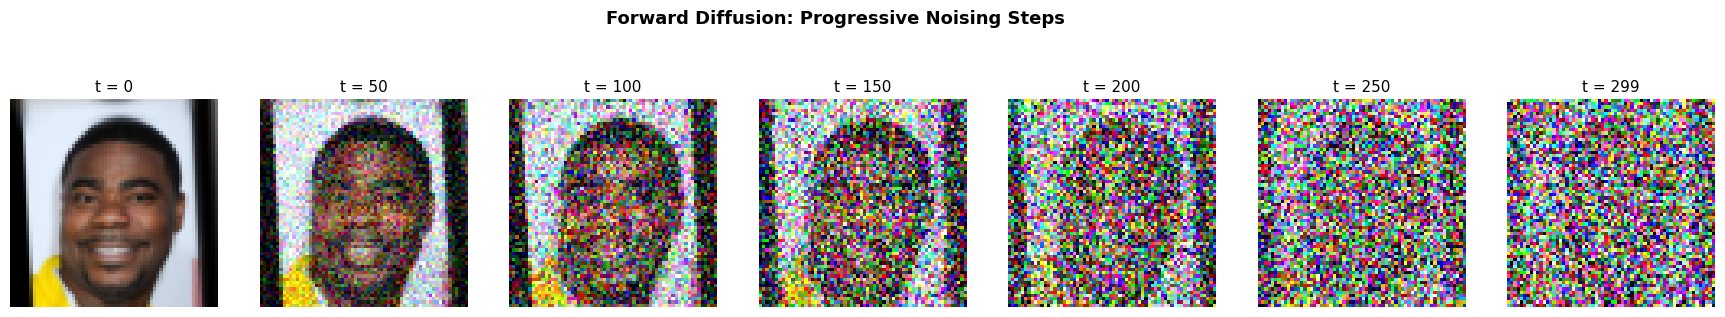

In [7]:
class GaussianDiffusion:
    def __init__(self, T: int, beta_start: float, beta_end: float, device):
        self.T      = T
        self.device = device

        betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
        alphas          = 1.0 - betas
        alphas_cumprod  = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.betas                  = betas.to(device)
        self.alphas                 = alphas.to(device)
        self.alphas_cumprod         = alphas_cumprod.to(device)
        self.alphas_cumprod_prev    = alphas_cumprod_prev.to(device)

        self.sqrt_alphas_cumprod         = torch.sqrt(alphas_cumprod).to(device)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod).to(device)

        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.posterior_variance         = posterior_variance.to(device)
        self.posterior_log_variance     = torch.log(posterior_variance.clamp(min=1e-20)).to(device)

        self.posterior_mean_coef1 = (torch.sqrt(alphas_cumprod_prev) * betas / (1.0 - alphas_cumprod)).to(device)
        self.posterior_mean_coef2 = (torch.sqrt(alphas) * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)).to(device)

    @staticmethod
    def _extract(a, t, x_shape):
        batch = t.shape[0]
        out   = a.gather(0, t)
        return out.view(batch, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_ac    = self._extract(self.sqrt_alphas_cumprod,           t, x_start.shape)
        sqrt_1mac  = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)
        return sqrt_ac * x_start + sqrt_1mac * noise

    def predict_x0_from_noise(self, x_t, t, noise_pred):
        sqrt_ac   = self._extract(self.sqrt_alphas_cumprod,           t, x_t.shape)
        sqrt_1mac = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        return (x_t - sqrt_1mac * noise_pred) / sqrt_ac

    def q_posterior(self, x_start, x_t, t):
        mean = (
            self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_start
          + self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        var     = self._extract(self.posterior_variance,     t, x_t.shape)
        log_var = self._extract(self.posterior_log_variance, t, x_t.shape)
        return mean, var, log_var

    @torch.no_grad()
    def p_sample(self, model, x_t, t_idx):
        t_tensor = torch.full((x_t.shape[0],), t_idx, device=self.device, dtype=torch.long)
        noise_pred = model(x_t, t_tensor)

        x0_pred = self.predict_x0_from_noise(x_t, t_tensor, noise_pred)
        x0_pred = x0_pred.clamp(-1, 1)

        mean, _, log_var = self.q_posterior(x0_pred, x_t, t_tensor)

        noise = torch.randn_like(x_t) if t_idx > 0 else torch.zeros_like(x_t)
        return mean + (0.5 * log_var).exp() * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape, return_intermediates=False):
        model.eval()
        x = torch.randn(shape, device=self.device)
        intermediates = [x.clone()] if return_intermediates else []

        for t in tqdm(reversed(range(self.T)), desc='Sampling', total=self.T, leave=False):
            x = self.p_sample(model, x, t)
            if return_intermediates and t % (self.T // 10) == 0:
                intermediates.append(x.clone())

        if return_intermediates:
            return x, intermediates
        return x

diffusion = GaussianDiffusion(cfg.T, cfg.BETA_START, cfg.BETA_END, device)

# ── Visualise forward diffusion ───────────────────────────────────
vis_img = sample_batch[0:1].to(device)
steps_to_show = [0, 50, 100, 150, 200, 250, cfg.T - 1]
noisy_imgs    = []

for t_val in steps_to_show:
    if t_val == 0:
        noisy_imgs.append(vis_img.squeeze(0).cpu())
    else:
        t_tensor = torch.tensor([t_val], device=device)
        noisy    = diffusion.q_sample(vis_img, t_tensor)
        noisy_imgs.append(noisy.squeeze(0).cpu())

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(22, 4))
for ax, img_t, t_val in zip(axes, noisy_imgs, steps_to_show):
    ax.imshow(denorm(img_t).permute(1, 2, 0).numpy())
    ax.set_title(f't = {t_val}', fontsize=11)
    ax.axis('off')
plt.suptitle('Forward Diffusion: Progressive Noising Steps', fontsize=13, fontweight='bold')
plt.show()

In [8]:
class SinusoidalPositionEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half_dim  = self.dim // 2
        emb_scale = math.log(10_000) / (half_dim - 1)
        emb       = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
        emb       = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class TimeEmbeddingMLP(nn.Module):
    def __init__(self, emb_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalPositionEmbedding(emb_dim),
            nn.Linear(emb_dim, out_dim * 4),
            nn.SiLU(),
            nn.Linear(out_dim * 4, out_dim),
        )
    def forward(self, t):
        return self.net(t)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int, groups: int = 8):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch * 2))

        self.block1 = nn.Sequential(
            nn.GroupNorm(groups, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h       = self.block1(x)
        t_out   = self.time_mlp(time_emb)
        scale, shift = t_out.chunk(2, dim=-1)
        h = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class SelfAttention(nn.Module):
    def __init__(self, channels: int, groups: int = 8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, channels)
        self.qkv  = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h          = self.norm(x)
        qkv        = self.qkv(h).view(B, 3, C, H * W)
        q, k, v    = qkv.unbind(1)
        scale       = C ** -0.5
        attn        = torch.softmax(torch.bmm(q.transpose(1, 2), k) * scale, dim=-1)
        out         = torch.bmm(v, attn.transpose(1, 2)).view(B, C, H, W)
        return x + self.proj(out)

class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x): return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, x): return self.conv(self.up(x))

class UNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=64, time_emb_dim=256, num_res_blocks=2):
        super().__init__()
        ch = base_channels
        ch_mult = (1, 2, 4)
        channels = [ch * m for m in ch_mult]

        self.time_mlp = TimeEmbeddingMLP(time_emb_dim, time_emb_dim)
        self.init_conv = nn.Conv2d(in_channels, channels[0], 3, padding=1)

        self.enc_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        in_ch = channels[0]
        self.skip_channels = []

        for level, out_ch in enumerate(channels):
            blocks = nn.ModuleList()
            for _ in range(num_res_blocks):
                blocks.append(ResidualBlock(in_ch, out_ch, time_emb_dim))
                in_ch = out_ch
            self.enc_blocks.append(blocks)
            self.skip_channels.append(out_ch)
            if level < len(channels) - 1:
                self.downsamples.append(Downsample(out_ch))
            else:
                self.downsamples.append(nn.Identity())

        btn_ch = channels[-1]
        self.mid_block1  = ResidualBlock(btn_ch, btn_ch, time_emb_dim)
        self.mid_attn    = SelfAttention(btn_ch)
        self.mid_block2  = ResidualBlock(btn_ch, btn_ch, time_emb_dim)

        self.dec_blocks   = nn.ModuleList()
        self.upsamples    = nn.ModuleList()
        rev_channels = list(reversed(channels))

        for level, out_ch in enumerate(rev_channels):
            skip_ch = self.skip_channels[-(level + 1)]
            blocks  = nn.ModuleList()
            for i in range(num_res_blocks + 1):
                block_in = (in_ch + skip_ch) if i == 0 else out_ch
                blocks.append(ResidualBlock(block_in, out_ch, time_emb_dim))
            in_ch = out_ch
            self.dec_blocks.append(blocks)
            if level < len(rev_channels) - 1:
                self.upsamples.append(Upsample(out_ch))
            else:
                self.upsamples.append(nn.Identity())

        self.out_norm = nn.GroupNorm(8, channels[0])
        self.out_act  = nn.SiLU()
        self.out_conv = nn.Conv2d(channels[0], in_channels, 1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        x = self.init_conv(x)

        skips = []
        for blocks, down in zip(self.enc_blocks, self.downsamples):
            for blk in blocks: x = blk(x, t_emb)
            skips.append(x)
            x = down(x)

        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        for blocks, up, skip in zip(self.dec_blocks, self.upsamples, reversed(skips)):
            x = torch.cat([x, skip], dim=1)
            for blk in blocks: x = blk(x, t_emb)
            x = up(x)

        x = self.out_norm(x)
        x = self.out_act(x)
        return self.out_conv(x)

model = UNet(
    in_channels    = 3,
    base_channels  = cfg.BASE_CHANNELS,
    time_emb_dim   = cfg.TIME_EMB_DIM,
    num_res_blocks = cfg.NUM_RES_BLOCKS,
).to(device)

if n_gpus > 1:
    model = nn.DataParallel(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net created ✓  |  Parameters: {n_params/1e6:.2f}M')

U-Net created ✓  |  Parameters: 14.21M


In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)
scaler    = GradScaler(enabled=cfg.MIXED_PRECISION)
loss_fn = nn.MSELoss()

train_losses   = []
best_loss      = float('inf')
start_epoch    = 0
ckpt_path = f'{cfg.SAVE_DIR}/best_model.pth'

def train_one_epoch(model, dataloader, optimizer, scaler, diffusion, epoch):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{cfg.EPOCHS}', leave=True)

    for step, x0 in enumerate(pbar):
        x0 = x0.to(device, non_blocking=True)
        B  = x0.shape[0]

        t = torch.randint(0, cfg.T, (B,), device=device)
        noise = torch.randn_like(x0)
        x_t   = diffusion.q_sample(x0, t, noise)

        with autocast(enabled=cfg.MIXED_PRECISION):
            noise_pred = model(x_t, t)
            loss       = loss_fn(noise_pred, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if cfg.GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.5f}', 'lr'  : f'{optimizer.param_groups[0]["lr"]:.2e}'})

    return epoch_loss / len(dataloader)

print('Starting training …')
total_start = time.time()

for epoch in range(start_epoch, cfg.EPOCHS):
    avg_loss = train_one_epoch(model, dataloader, optimizer, scaler, diffusion, epoch)
    scheduler.step()
    train_losses.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({'epoch': epoch, 'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                    'loss': best_loss, 'losses': train_losses, 'config': vars(cfg),
        }, ckpt_path)

elapsed = time.time() - total_start
print(f'\nTraining complete in {elapsed/60:.1f} min  |  Best loss: {best_loss:.5f}')

# Plot Loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train MSE Loss')
ax.set_title('Training Loss vs Epochs')
ax.legend()
plt.show()

Starting training …


/tmp/ipykernel_6112/1012516667.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=cfg.MIXED_PRECISION)


Epoch 1/30:   0%|          | 0/1875 [00:00<?, ?it/s]

/tmp/ipykernel_6112/1012516667.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.MIXED_PRECISION):


Epoch 2/30:   0%|          | 0/1875 [00:00<?, ?it/s]

...

Epoch 17/30:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 18/30:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 19/30:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 20/30:   0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

Generating images from pure Gaussian noise …


Sampling:   0%|          | 0/300 [00:00<?, ?it/s]

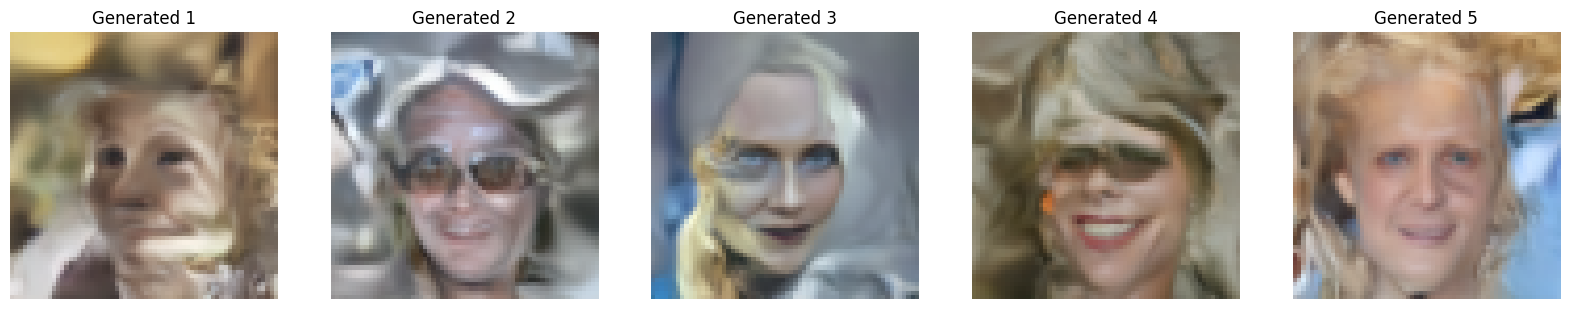

Reconstructing:   0%|          | 0/150 [00:00<?, ?it/s]

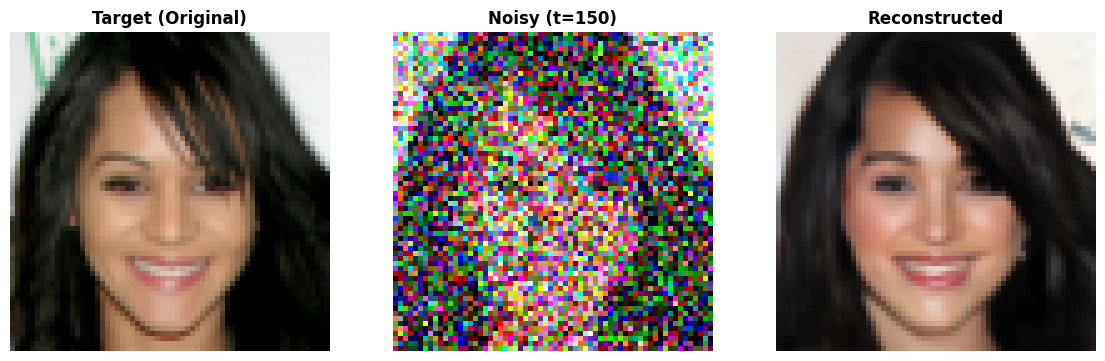

In [10]:
best_ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(best_ckpt['model'])
model.eval()

# Generate from pure noise
print('Generating images from pure Gaussian noise …')
gen_shape = (cfg.NUM_SAMPLE_IMGS, 3, cfg.IMG_SIZE, cfg.IMG_SIZE)
generated, intermediates = diffusion.p_sample_loop(model, gen_shape, return_intermediates=True)

fig, axes = plt.subplots(1, cfg.NUM_SAMPLE_IMGS, figsize=(20, 4))
for i, ax in enumerate(axes):
    ax.imshow(denorm(generated[i]).permute(1, 2, 0).cpu().numpy())
    ax.set_title(f'Generated {i+1}')
    ax.axis('off')
plt.show()

# Reconstruction Task
def reconstruct_image(model, diffusion, target_tensor, noise_level_frac=0.5):
    model.eval()
    x0 = target_tensor.unsqueeze(0).to(device)
    t_start = int(diffusion.T * noise_level_frac)

    t_tensor = torch.tensor([t_start], device=device)
    noise    = torch.randn_like(x0)
    x_t      = diffusion.q_sample(x0, t_tensor, noise)

    x = x_t.clone()
    with torch.no_grad():
        for t_idx in tqdm(reversed(range(t_start)), desc='Reconstructing', total=t_start, leave=False):
            x = diffusion.p_sample(model, x, t_idx)
    return x.squeeze(0).cpu()

target_img = dataset[0]
reconstructed = reconstruct_image(model, diffusion, target_img, noise_level_frac=0.5)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
orig_np  = denorm(target_img).permute(1, 2, 0).numpy()
noisy_np = denorm(diffusion.q_sample(target_img.unsqueeze(0).to(device), torch.tensor([cfg.T // 2], device=device)).squeeze(0).cpu()).permute(1, 2, 0).numpy()
recon_np = denorm(reconstructed).permute(1, 2, 0).numpy()

for ax, img, title in zip(axes, [orig_np, noisy_np, recon_np], ['Target (Original)', f'Noisy (t={cfg.T//2})', 'Reconstructed']):
    ax.imshow(img.clip(0, 1))
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
plt.show()

In [11]:
def compute_metrics(original_tensor, generated_tensor):
    orig_np = denorm(original_tensor).permute(1, 2, 0).numpy().clip(0, 1)
    gen_np  = denorm(generated_tensor).permute(1, 2, 0).numpy().clip(0, 1)
    psnr_val = psnr_metric(orig_np, gen_np, data_range=1.0)
    ssim_val = ssim_metric(orig_np, gen_np, data_range=1.0, channel_axis=-1,
                            win_size=min(7, orig_np.shape[0] - 1 if orig_np.shape[0] % 2 == 0 else orig_np.shape[0]))
    return psnr_val, ssim_val

print('Computing PSNR & SSIM on 5 test images…')
for i in range(5):
    tgt  = dataset[i]
    rec  = reconstruct_image(model, diffusion, tgt, noise_level_frac=0.4)
    p, s = compute_metrics(tgt, rec)
    print(f'  Image {i+1}: PSNR = {p:.2f} dB  |  SSIM = {s:.4f}')

Computing PSNR & SSIM on 5 test images…


Reconstructing:   0%|          | 0/120 [00:00<?, ?it/s]

  Image 1: PSNR = 23.71 dB  |  SSIM = 0.7195


Reconstructing:   0%|          | 0/120 [00:00<?, ?it/s]

  Image 2: PSNR = 21.10 dB  |  SSIM = 0.7730


...

  Image 3: PSNR = 22.19 dB  |  SSIM = 0.7399


Reconstructing:   0%|          | 0/120 [00:00<?, ?it/s]

  Image 4: PSNR = 22.17 dB  |  SSIM = 0.6739


Reconstructing:   0%|          | 0/120 [00:00<?, ?it/s]

  Image 5: PSNR = 23.40 dB  |  SSIM = 0.7181


In [12]:
import gradio as gr

@torch.no_grad()
def gradio_generate(num_images, show_steps, seed):
    torch.manual_seed(int(seed))
    model.eval()
    n = int(num_images)

    x = torch.randn(n, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
    collect_at  = set(range(0, cfg.T, max(1, cfg.T // int(show_steps))))
    frame_list  = []

    for t_idx in reversed(range(cfg.T)):
        x = diffusion.p_sample(model, x, t_idx)
        if t_idx in collect_at:
            frame_list.append(denorm(x[0]).permute(1,2,0).cpu().numpy().clip(0,1))

    final_pils = [Image.fromarray((denorm(x[i]).permute(1,2,0).cpu().numpy().clip(0,1)*255).astype(np.uint8)) for i in range(n)]

    n_frames = len(frame_list)
    strip_w  = cfg.IMG_SIZE * n_frames
    strip    = np.zeros((cfg.IMG_SIZE, strip_w, 3), dtype=np.uint8)
    for idx, frame in enumerate(frame_list):
        strip[:, idx*cfg.IMG_SIZE:(idx+1)*cfg.IMG_SIZE, :] = (frame * 255).astype(np.uint8)
    strip_pil = Image.fromarray(strip)

    return final_pils + [strip_pil]

with gr.Blocks(title='DDPM Image Generator') as demo:
    gr.Markdown("# 🎨 DDPM Image Generator\nBuilt from scratch with PyTorch")
    with gr.Row():
        with gr.Column(scale=1):
            num_imgs   = gr.Slider(1, 5,  value=3, step=1,  label='Images')
            num_steps  = gr.Slider(5, 20, value=10, step=1, label='Steps to Show')
            seed_input = gr.Number(value=42, label='Random Seed', precision=0)
            gen_btn    = gr.Button('🚀 Generate')
        with gr.Column(scale=3):
            output_gallery = gr.Gallery(label='Generated Images')
            step_strip = gr.Image(label='Denoising Step Strip (Image 1)', type='pil')

    gen_btn.click(fn=gradio_generate, inputs=[num_imgs, num_steps, seed_input], outputs=[output_gallery, step_strip])

print('Launching Gradio app…')
demo.launch(share=True, debug=False)

Launching Gradio app…
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://49be57addf0cd6c4fe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
